# Day 12 – Exploratory Data Analysis (EDA)

## Objective

The objective of this notebook is to perform Exploratory Data Analysis (EDA) on the cleaned LLM Platform Analytics datasets.

The analysis focuses on:

- User engagement
- Platform usage
- Operational performance
- Token consumption
- Cost analysis
- Response quality
- Platform reliability
- Temporal usage patterns

The insights generated from this analysis will support Power BI dashboard development and data-driven decision-making to improve user engagement, product adoption, operational efficiency, platform reliability, and cost optimization.

In [170]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

## Load Cleaned Datasets


In [171]:
interactions = pd.read_csv("../data/cleaned/llm_system_interactions_cleaned.csv")

sessions = pd.read_csv("../data/cleaned/llm_system_sessions_summary_cleaned.csv")

users = pd.read_csv("../data/cleaned/llm_system_users_summary_cleaned.csv")

prompts = pd.read_csv("../data/cleaned/llm_system_prompts_lookup_cleaned.csv")

## Dataset Overview

This section provides a quick overview of all cleaned datasets including the number of rows and columns.

In [172]:
print("Interactions :", interactions.shape)
print("Sessions     :", sessions.shape)
print("Users        :", users.shape)
print("Prompts      :", prompts.shape)

Interactions : (9000, 55)
Sessions     : (1595, 37)
Users        : (438, 21)
Prompts      : (36, 14)


## Preview of Datasets

In [173]:
display(interactions.head())

display(sessions.head())

display(users.head())

display(prompts.head())

,interaction_id,session_id,user_id,timestamp_utc,split,channel,use_case,country_code,region,account_tier,segment,instruction_template,model_provider,model_name,temperature,top_p,max_tokens,prompt_tokens,completion_tokens,total_tokens,latency_ms,cost_usd,response_quality_score,is_failure,failure_type,hallucination_flag,toxicity_flag,safety_block_flag,formatting_error_flag,tool_error_flag,latency_timeout_flag,tool_calls_count,tools_used,user_feedback_score,user_feedback_label,user_reported_issue,retry_index,repair_strategy,final_resolution_state,business_impact_tag,request_text,response_text_snippet,tokens_per_second,date_utc,hour_of_day_utc,day_of_week,is_weekend,is_peak_hour,prompt_to_completion_ratio,request_text_template,instruction_text,user_feedback_observed,prompt_id,response_text_snippet_len_chars,response_text_snippet_is_truncated
0,INT000001,S01207,U00013,2025-03-25 11:14:35+00:00,train,web_app,coding_assistant,BR,AMER,pro,enterprise_team,creative_writer,meta,llama-3.1-70b,0.257,0.898,768,186,422,608,615,0.12160,0.846,False,none,False,False,False,False,False,False,0,none,2.0,positive,False,0,none,auto_resolved,medium,Can you help me debug this? I'm getting a Pyth...,Let's turn this into a reliable workflow. Goal...,988.617886,2025-03-25,11,1,False,True,0.4408,I'm getting a Python error: `NullPointerExcept...,You are a senior software engineer helping use...,True,83c939e9b891e505ac06548e158556e919317a64,216,True
1,INT000002,S01119,U00017,2025-02-23 04:08:56+00:00,val,mobile_app,customer_support,IN,APAC,free,individual,general_assistant,anthropic,claude-3.5-sonnet,0.806,0.890,768,701,410,1111,1194,0.35552,0.352,True,formatting_error,False,False,False,True,False,False,0,none,NaN,no_feedback,False,0,enable_tools,escalated_to_human,high,I'm stuck on this and need some guidance: Our ...,Let's break this down into actionable steps. S...,930.485762,2025-02-23,4,6,True,False,1.7098,Our customer is getting an error when trying t...,You are a helpful customer support assistant f...,False,a52fb80193c7c0769c0836852624f4b025a04d2a,207,True
2,INT000003,S00653,U00155,2025-02-25 17:31:08+00:00,train,web_app,brainstorming,GB,EMEA,free,team,code_assistant_secure,google,gemini-1.5-pro,0.412,0.898,1024,425,131,556,1196,0.17792,0.543,True,safety_block,False,False,True,False,False,False,0,none,NaN,no_feedback,False,0,manual_post_edit,abandoned,low,Context for you: Brainstorm taglines for a pro...,This is a common pattern; the fix is straightf...,464.882943,2025-02-25,17,1,False,True,3.2443,Brainstorm taglines for a productivity app tha...,You are a creative assistant helping users exp...,False,9886b059d7fa547dc6fd91d4a5c80abdb317022d,223,True
3,INT000004,S00103,U00263,2025-03-14 17:42:16+00:00,train,web_app,content_writing,AU,APAC,free,team,creative_writer,google,gemini-1.5-pro,0.637,0.822,1024,1173,545,1718,1266,0.54976,0.888,False,none,False,False,False,False,False,False,0,none,NaN,no_feedback,False,0,none,auto_resolved,high,I'm working on something and need help: Draft ...,Here's what I'd implement in production. Goal:...,1357.030016,2025-03-14,17,4,False,True,2.1523,Draft a friendly email announcing a small pric...,You are a writing assistant helping users craf...,False,469eb15f8b08d9b4130e14a6c3888f14e335a854,236,True
4,INT000005,S01553,U00118,2025-02-24 00:39:04+00:00,train,api,data_analysis,IN,APAC,enterprise,individual,support_strict,meta,llama-3.1-8b,0.414,0.949,512,65,431,496,833,0.02976,0.755,False,none,False,False,False,False,False,False,2,email_send|knowledge_lookup,0.0,neutral,False,0,none,auto_resolved,low,Quick question: I have a CSV with user session...,Let's turn this into a reliable workflow. Goal...,595.438175,2025-02-24,0,0,False,False,0.1508,I have a CSV with user sessions. Show me a qui...,You are a data analysis assistant helping user...,True,a15ac130f4f428f0efac738d5c68655674fccc6e,251,True


,session_id,user_id,use_case,channel,country_code,region,account_tier,segment,total_requests,failed_requests,failure_rate,avg_latency_ms,median_latency_ms,avg_response_quality_score,avg_tokens_per_request,requests_with_tools,share_requests_with_tools,n_retry_requests,escalations_to_human,csat_mean,csat_response_rate,risk_session_flag,total_cost_usd,total_tokens,avg_cost_per_request,cost_per_1k_tokens,avg_tokens_per_second,start_timestamp_utc,end_timestamp_utc,session_duration_seconds,session_duration_minutes,requests_per_minute,total_latency_ms,zero_duration_session_flag,total_latency_seconds,effective_session_duration_seconds,requests_per_minute_effective
0,S00001,U00408,data_analysis,web_app,AE,EMEA,pro,individual,6,4,0.6667,882.33,835.0,0.608,1511.3,3,0.500000,2,1,0.00,0.666667,True,1.26564,9068,0.210940,0.139572,1711.351724,2025-04-03 15:46:54+00:00,2025-04-03 16:44:08+00:00,3434.0,57.233333,0.104834,5294,False,5.294,3434.0,0.104834
1,S00002,U00408,brainstorming,internal_tool,AE,EMEA,pro,individual,9,1,0.1111,1053.33,1089.0,0.736,1284.8,1,0.111111,1,0,0.75,0.444444,False,1.30104,11563,0.144560,0.112518,1433.560694,2025-04-09 09:19:17+00:00,2025-04-09 11:23:39+00:00,7462.0,124.366667,0.072367,9480,False,9.480,7462.0,0.072367
2,S00003,U00003,customer_support,mobile_app,CA,AMER,free,individual,3,0,0.0000,894.67,659.0,0.751,882.7,1,0.333333,0,0,1.50,0.666667,False,0.84736,2648,0.282453,0.320000,1193.321291,2025-02-03 14:28:35+00:00,2025-02-03 14:40:31+00:00,716.0,11.933333,0.251397,2684,False,2.684,716.0,0.251397
3,S00004,U00237,data_analysis,web_app,GB,EMEA,free,team,2,1,0.5000,952.50,952.5,0.608,1116.0,1,0.500000,0,0,-0.50,1.000000,False,0.71424,2232,0.357120,0.320000,1158.893413,2025-03-06 15:26:57+00:00,2025-03-06 15:28:39+00:00,102.0,1.700000,1.176471,1905,False,1.905,102.0,1.176471
4,S00005,U00224,data_analysis,mobile_app,FR,EMEA,free,enterprise_team,7,2,0.2857,1392.43,1488.0,0.672,676.9,3,0.428571,2,2,2.00,0.142857,False,0.35932,4738,0.051331,0.075838,523.406497,2025-04-02 13:52:48+00:00,2025-04-02 14:42:31+00:00,2983.0,49.716667,0.140798,9747,False,9.747,2983.0,0.140798


,user_id,total_sessions,total_requests,total_failed_requests,overall_failure_rate,avg_csat,risk_sessions_share,escalations_per_100_sessions,total_cost_usd,total_tokens,avg_tokens_per_request,avg_requests_per_session,primary_use_case,primary_channel,dominant_segment,dominant_account_tier,dominant_country_code,dominant_region,high_risk_user_flag,high_risk_sessions_count,total_escalations
0,U00001,2,10,6,0.600000,-1.200000,0.5,100.0,1.63080,7568,756.800000,5.0,brainstorming,api,individual,free,IN,APAC,False,1,2
1,U00002,1,5,2,0.400000,0.666667,0.0,0.0,0.76648,8788,1757.600000,5.0,content_writing,web_app,team,pro,GB,EMEA,False,0,0
2,U00003,5,16,2,0.125000,1.000000,0.0,0.0,3.73612,15880,992.500000,3.2,customer_support,slack,individual,free,CA,AMER,False,0,0
3,U00004,5,37,9,0.243243,1.176471,0.2,80.0,5.34624,38270,1034.324324,7.4,customer_support,mobile_app,team,free,US,AMER,False,1,4
4,U00005,1,3,1,0.333333,2.000000,0.0,0.0,0.94920,3492,1164.000000,3.0,coding_assistant,web_app,team,free,US,AMER,False,0,0


,prompt_id,prompt_sha1,prompt_len,instruction_template,use_case,n_interactions,share_within_template,n_sessions,n_users,use_case_mismatch_count,instruction_text,instruction_id,instruction_sha1,instruction_len
0,2df52d847c72d1f6b37061123acb53282123086b,ea733c780cb54724e7f468aee787582220c4a104,162,analytics_helper,brainstorming,156,0.100322,101,97,0,You are a creative assistant helping users exp...,SP_ca1bb9120a23,ca1bb9120a23664b57e2cc37e43b8df7a43cafae,144
1,54f94ac4f6df7ccc4808605ae4fb839b7a1fbfb2,95ab088c59a1c77e680b2015d064083763a54d79,200,analytics_helper,coding_assistant,304,0.195498,181,149,0,You are a senior software engineer helping use...,SP_3eb46160306e,3eb46160306e8b6cbc4876b6be6abb4a89feb5cb,182
2,9716fa3b2c6fe39ac0f75ddaad781dfa757a0de9,831f6d7163e835f2ae48b7fad5d14c888b4eb8e2,180,analytics_helper,content_writing,265,0.170418,164,142,0,You are a writing assistant helping users craf...,SP_19bb5b9b4167,19bb5b9b416700ffd6ae7da808da052b4b88e996,162
3,598eba0ae15195966a9835b68c542f0b34fb88e4,870199b7b6c71f24b69ba2e003e9912665961f01,181,analytics_helper,customer_support,465,0.299035,296,218,0,You are a helpful customer support assistant f...,SP_afbdfcb7694b,afbdfcb7694bd84cf4db575f3c1eed266714bd35,163
4,fbaac57cdb64395ff60fbf79b148e22caaff1431,8177380ba6140d1707221fe0448c6c5ebfe3dd6e,186,analytics_helper,data_analysis,230,0.147910,156,129,0,You are a data analysis assistant helping user...,SP_cf1ff26ed509,cf1ff26ed50940569363dfec41666e75134fe802,168


## Dataset Information

Inspect column names, data types, and memory usage for each dataset.

In [174]:
print("Interactions")
interactions.info()

print("\nSessions")
sessions.info()

print("\nUsers")
users.info()

print("\nPrompts")
prompts.info()

Interactions
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 55 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   interaction_id                      9000 non-null   object 
 1   session_id                          9000 non-null   object 
 2   user_id                             9000 non-null   object 
 3   timestamp_utc                       9000 non-null   object 
 4   split                               9000 non-null   object 
 5   channel                             9000 non-null   object 
 6   use_case                            9000 non-null   object 
 7   country_code                        9000 non-null   object 
 8   region                              9000 non-null   object 
 9   account_tier                        9000 non-null   object 
 10  segment                             9000 non-null   object 
 11  instruction_template          

## Summary Statistics

Generate descriptive statistics for all numerical columns.

In [175]:
display(interactions.describe())

display(sessions.describe())

display(users.describe())

display(prompts.describe())

,temperature,top_p,max_tokens,prompt_tokens,completion_tokens,total_tokens,latency_ms,cost_usd,response_quality_score,tool_calls_count,user_feedback_score,retry_index,tokens_per_second,hour_of_day_utc,day_of_week,prompt_to_completion_ratio,response_text_snippet_len_chars
count,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,4880.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000
mean,0.484236,0.900354,1018.140444,703.202667,390.405444,1093.608111,1215.247222,0.194243,0.723823,0.541000,0.603893,0.236222,1097.418337,11.847444,2.482111,4.218613,228.677778
std,0.249971,0.049246,508.870336,421.017090,237.820051,497.106237,572.432030,0.191658,0.170150,0.966196,1.334989,0.575627,742.042109,6.178131,1.811457,9.878679,19.256123
min,0.000000,0.707000,256.000000,13.000000,5.000000,29.000000,156.000000,0.000240,0.088000,0.000000,-2.000000,0.000000,27.443106,0.000000,0.000000,0.023400,180.000000
25%,0.276000,0.867000,512.000000,345.000000,204.000000,719.000000,812.000000,0.029880,0.607000,0.000000,0.000000,0.000000,571.151883,8.000000,1.000000,0.912250,215.000000
50%,0.459500,0.900000,1024.000000,685.000000,371.000000,1070.000000,1098.000000,0.132660,0.729000,0.000000,1.000000,0.000000,936.438323,11.000000,2.000000,1.799100,233.000000
75%,0.678000,0.934000,1536.000000,1019.000000,531.000000,1430.000000,1484.000000,0.312340,0.853000,1.000000,2.000000,0.000000,1440.181396,16.000000,4.000000,3.568300,244.000000
max,1.200000,1.000000,2048.000000,1910.000000,1116.000000,2754.000000,5622.000000,1.046800,1.000000,3.000000,2.000000,3.000000,7657.777778,23.000000,6.000000,208.166700,263.000000


,total_requests,failed_requests,failure_rate,avg_latency_ms,median_latency_ms,avg_response_quality_score,avg_tokens_per_request,requests_with_tools,share_requests_with_tools,n_retry_requests,escalations_to_human,csat_mean,csat_response_rate,total_cost_usd,total_tokens,avg_cost_per_request,cost_per_1k_tokens,avg_tokens_per_second,session_duration_seconds,session_duration_minutes,requests_per_minute,total_latency_ms,total_latency_seconds,effective_session_duration_seconds,requests_per_minute_effective
count,1595.000000,1595.000000,1595.000000,1595.000000,1595.000000,1595.000000,1595.000000,1595.000000,1595.000000,1595.000000,1595.000000,1532.000000,1595.000000,1595.000000,1595.000000,1595.000000,1595.000000,1595.000000,1595.000000,1595.000000,1560.000000,1595.000000,1595.000000,1595.000000,1595.000000
mean,5.642633,1.603135,0.283482,1213.001091,1133.442320,0.723597,1091.808213,1.611285,0.285319,0.985580,0.978683,0.614472,0.545653,1.096044,6170.829467,0.194282,0.178244,1098.922452,3510.462696,58.507712,0.355435,6857.194357,6.857194,3510.487132,1.747807
std,2.337344,1.356657,0.224518,272.058105,277.893517,0.083308,281.231254,1.596537,0.265078,1.003966,1.017191,0.894956,0.234908,0.662901,3023.718777,0.097153,0.073026,383.532066,3535.120545,58.918676,1.861722,3167.710490,3.167710,3535.096269,10.307026
min,1.000000,0.000000,0.000000,366.000000,366.000000,0.317000,35.000000,0.000000,0.000000,0.000000,0.000000,-2.000000,0.000000,0.005400,35.000000,0.003840,0.003988,54.517134,0.000000,0.000000,0.027531,366.000000,0.366000,0.366000,0.027531
25%,4.000000,1.000000,0.125000,1030.800000,950.500000,0.674000,896.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.400000,0.597760,3973.000000,0.129951,0.127799,849.479755,701.000000,11.683333,0.072363,4437.500000,4.437500,701.000000,0.074470
50%,5.000000,1.000000,0.250000,1189.500000,1100.000000,0.726000,1064.300000,1.000000,0.250000,1.000000,1.000000,0.690476,0.500000,1.009040,5723.000000,0.184360,0.177369,1033.379473,1794.000000,29.900000,0.162696,6547.000000,6.547000,1794.000000,0.165746
75%,7.000000,2.000000,0.400000,1367.810000,1276.250000,0.776000,1270.850000,3.000000,0.500000,2.000000,2.000000,1.250000,0.666667,1.484820,8031.500000,0.246000,0.228397,1314.575857,6023.000000,100.383333,0.320856,8924.500000,8.924500,6023.000000,0.338111
max,14.000000,8.000000,1.000000,2916.330000,2558.000000,0.980000,2176.000000,7.000000,1.000000,6.000000,6.000000,2.000000,1.000000,4.142600,16824.000000,0.870400,0.400000,3434.439179,13952.000000,232.533333,60.000000,19260.000000,19.260000,13952.000000,163.934426


,total_sessions,total_requests,total_failed_requests,overall_failure_rate,avg_csat,risk_sessions_share,escalations_per_100_sessions,total_cost_usd,total_tokens,avg_tokens_per_request,avg_requests_per_session,high_risk_sessions_count,total_escalations
count,438.000000,438.000000,438.000000,438.000000,435.000000,438.000000,438.000000,438.000000,438.000000,438.000000,438.000000,438.000000,438.000000
mean,3.641553,20.547945,5.837900,0.286963,0.606128,0.198147,96.009459,3.991302,22471.399543,1091.671508,5.662679,0.728311,3.563927
std,1.791618,10.782486,3.914852,0.138831,0.550241,0.238454,59.702013,2.315979,12606.233968,214.113136,1.434991,0.823940,2.615615
min,1.000000,1.000000,0.000000,0.000000,-2.000000,0.000000,0.000000,0.011200,35.000000,35.000000,1.000000,0.000000,0.000000
25%,2.000000,13.000000,3.000000,0.200000,0.333333,0.000000,50.000000,2.315220,12736.000000,930.782086,4.750000,0.000000,2.000000
50%,3.000000,20.000000,5.000000,0.277778,0.615385,0.166700,100.000000,3.721360,21039.000000,1042.020833,5.535714,1.000000,3.000000
75%,5.000000,27.000000,8.000000,0.360000,1.000000,0.333300,133.333333,5.196050,29574.500000,1260.734848,6.500000,1.000000,5.000000
max,10.000000,51.000000,20.000000,0.833333,2.000000,1.000000,400.000000,12.499120,61782.000000,1776.600000,10.500000,4.000000,14.000000


,prompt_len,n_interactions,share_within_template,n_sessions,n_users,use_case_mismatch_count,instruction_len
count,36.000000,36.000000,36.000000,36.000000,36.000000,36.0,36.000000
mean,185.666667,250.000000,0.166667,162.750000,134.083333,0.0,166.833333
std,13.427052,107.353355,0.071335,68.384783,43.496059,0.0,13.228757
min,160.000000,126.000000,0.084734,80.000000,74.000000,0.0,144.000000
25%,179.750000,153.750000,0.101175,101.750000,96.500000,0.0,162.000000
50%,185.000000,239.500000,0.163178,158.000000,132.500000,0.0,165.500000
75%,199.000000,269.750000,0.183341,181.000000,150.000000,0.0,182.000000
max,205.000000,470.000000,0.311671,297.000000,218.000000,0.0,182.000000


---

## Token Usage Analysis

This section analyzes the distribution of token consumption across all LLM interactions.

Token usage is one of the primary operational metrics because it directly impacts platform utilization, inference cost, and model efficiency.

In [176]:
token_columns = [
    "prompt_tokens",
    "completion_tokens",
    "total_tokens"
]

interactions[token_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
prompt_tokens,9000.0,703.202667,421.017090,13.0,345.0,685.0,1019.0,1910.0
completion_tokens,9000.0,390.405444,237.820051,5.0,204.0,371.0,531.0,1116.0
total_tokens,9000.0,1093.608111,497.106237,29.0,719.0,1070.0,1430.0,2754.0


### Distribution of Total Tokens

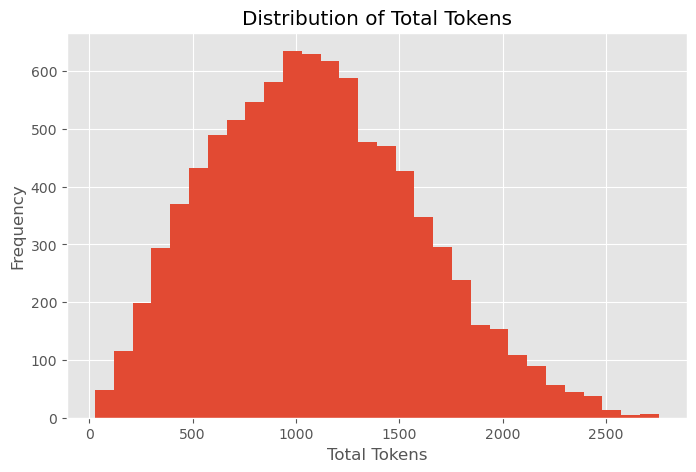

In [177]:
plt.figure(figsize=(8,5))

plt.hist(interactions["total_tokens"], bins=30)

plt.title("Distribution of Total Tokens")
plt.xlabel("Total Tokens")
plt.ylabel("Frequency")

plt.show()

### Boxplot of Total Tokens

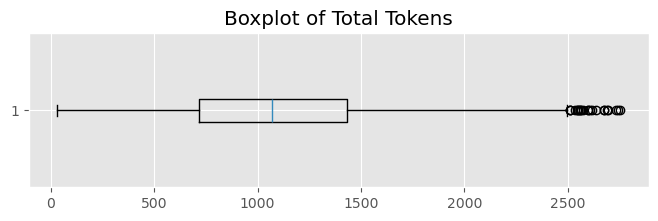

In [178]:
plt.figure(figsize=(8,2))

plt.boxplot(interactions["total_tokens"], vert=False)

plt.title("Boxplot of Total Tokens")

plt.show()

### Insight

- Most interactions consume approximately **700–1400 tokens**.
- A few interactions consume significantly higher tokens, indicating heavy LLM requests.
- Token consumption is moderately right-skewed, suggesting occasional high-resource requests.

## Response Latency Analysis

Latency measures how quickly the platform responds to user requests.

Lower latency generally provides a better user experience.

In [179]:
interactions["latency_ms"].describe()

count    9000.000000
mean     1215.247222
std       572.432030
min       156.000000
25%       812.000000
50%      1098.000000
75%      1484.000000
max      5622.000000
Name: latency_ms, dtype: float64

### Distribution of Response Latency

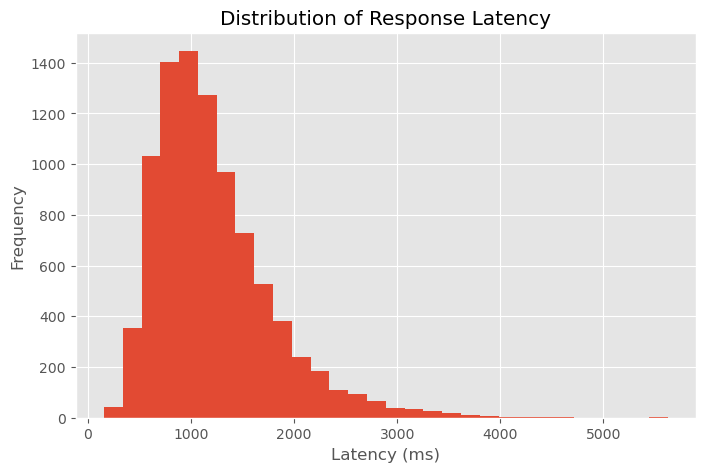

In [180]:
plt.figure(figsize=(8,5))

plt.hist(interactions["latency_ms"], bins=30)

plt.title("Distribution of Response Latency")

plt.xlabel("Latency (ms)")
plt.ylabel("Frequency")

plt.show()

### Boxplot of Response Latency

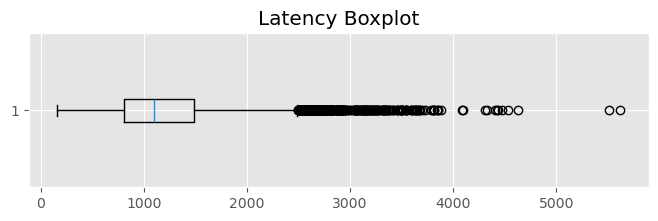

In [181]:
plt.figure(figsize=(8,2))

plt.boxplot(interactions["latency_ms"], vert=False)

plt.title("Latency Boxplot")

plt.show()

### Insight

- Most requests complete within approximately **800–1500 ms**.
- A small number of requests exhibit much higher latency.
- These high-latency interactions may require operational investigation.

## Latency Timeout Analysis

This section examines the frequency of latency timeout events.

Latency timeout analysis helps evaluate response reliability and identify requests that exceeded acceptable response times.

In [182]:
timeout_counts = interactions["latency_timeout_flag"].value_counts()

timeout_counts

latency_timeout_flag
False    8775
True      225
Name: count, dtype: int64

### Latency Timeout Distribution

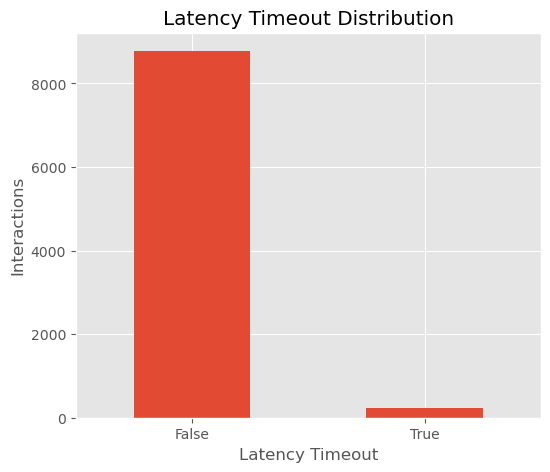

In [183]:
plt.figure(figsize=(6,5))

timeout_counts.plot(kind="bar")

plt.title("Latency Timeout Distribution")
plt.xlabel("Latency Timeout")
plt.ylabel("Interactions")

plt.xticks(rotation=0)

plt.show()

### Insight

- Most interactions complete without exceeding the latency timeout threshold.
- A small number of requests experience timeout events.
- Monitoring timeout frequency helps improve platform responsiveness and operational performance.

## Platform Cost Analysis

Each interaction incurs an operational cost based on token usage and model inference.

Analyzing cost distribution helps identify expensive workloads.

In [184]:
interactions["cost_usd"].describe()

count    9000.000000
mean        0.194243
std         0.191658
min         0.000240
25%         0.029880
50%         0.132660
75%         0.312340
max         1.046800
Name: cost_usd, dtype: float64

### Distribution of Cost

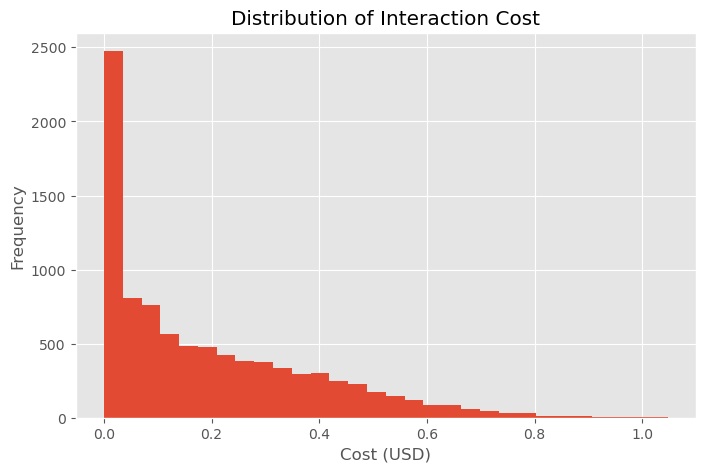

In [185]:
plt.figure(figsize=(8,5))

plt.hist(interactions["cost_usd"], bins=30)

plt.title("Distribution of Interaction Cost")

plt.xlabel("Cost (USD)")
plt.ylabel("Frequency")

plt.show()

### Insight

- Most interactions incur relatively low inference costs.
- A small number of interactions contribute disproportionately to total platform expenditure.

---

## Country-wise Interaction Analysis

This section analyzes the geographical distribution of platform interactions across different countries.

Understanding country-level usage helps identify key markets and regional adoption patterns.

In [186]:
country_counts = interactions["country_code"].value_counts()

country_counts

country_code
IN    1517
US    1370
GB    1085
FR    1019
BR     927
EG     881
DE     655
AE     594
CA     484
AU     468
Name: count, dtype: int64

### Top Countries by Number of Interactions

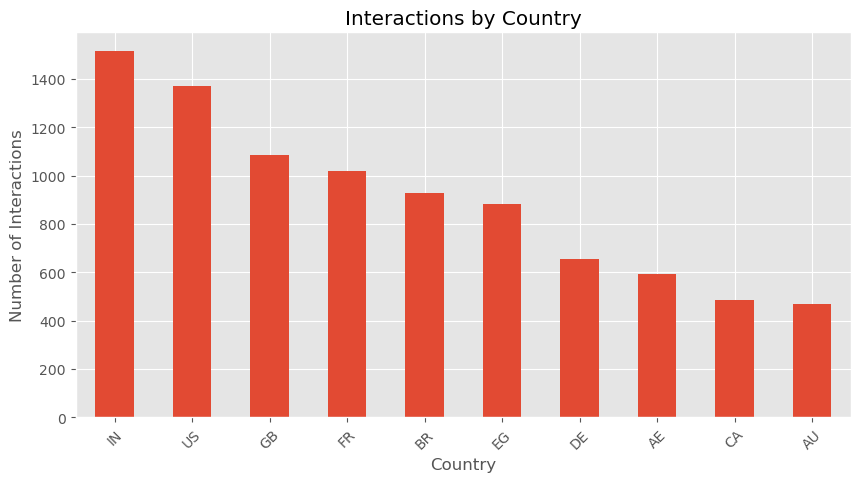

In [187]:
plt.figure(figsize=(10,5))

country_counts.plot(kind="bar")

plt.title("Interactions by Country")
plt.xlabel("Country")
plt.ylabel("Number of Interactions")

plt.xticks(rotation=45)

plt.show()

### Insight

- Platform usage varies across countries.
- The countries with the highest interaction counts represent the major user base.
- These regions can be prioritized for platform optimization and expansion.

## Account Tier Analysis

This section analyzes interaction distribution across subscription tiers.

It helps understand adoption among Free, Pro, and Enterprise users.

In [188]:
tier_counts = interactions["account_tier"].value_counts()

tier_counts

account_tier
free          5007
pro           2532
enterprise    1461
Name: count, dtype: int64

### Interaction Distribution by Account Tier

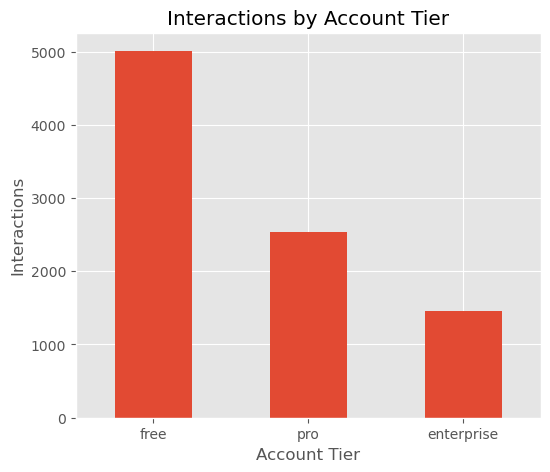

In [189]:
plt.figure(figsize=(6,5))

tier_counts.plot(kind="bar")

plt.title("Interactions by Account Tier")
plt.xlabel("Account Tier")
plt.ylabel("Interactions")

plt.xticks(rotation=0)

plt.show()

### Insight

- The chart highlights which subscription tier generates the highest platform activity.
- This information is useful for customer segmentation and revenue planning.

## Interaction Channel Analysis

This section evaluates which channels are most frequently used to access the LLM platform.

In [190]:
channel_counts = interactions["channel"].value_counts()

channel_counts

channel
web_app          3644
api              2260
mobile_app       1215
internal_tool     943
slack             938
Name: count, dtype: int64

### Interactions by Channel

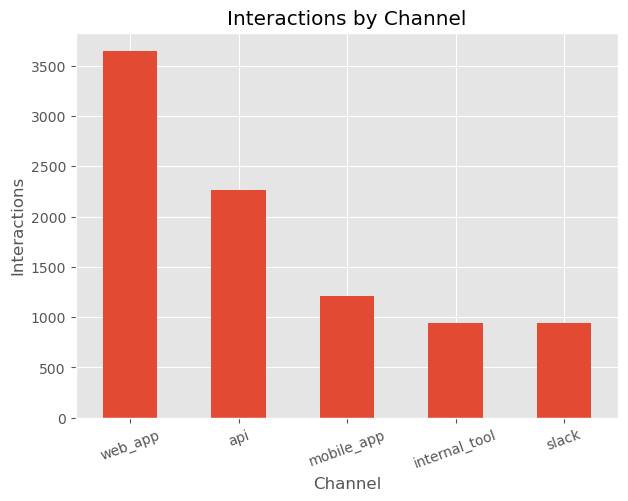

In [191]:
plt.figure(figsize=(7,5))

channel_counts.plot(kind="bar")

plt.title("Interactions by Channel")
plt.xlabel("Channel")
plt.ylabel("Interactions")

plt.xticks(rotation=20)

plt.show()

### Insight

- Different access channels contribute differently to total platform usage.
- Identifying the dominant channel helps optimize deployment and user experience.

## Region-wise Interaction Analysis

This section analyzes interaction distribution across different geographical regions.

Region analysis helps identify platform adoption across global markets.

In [192]:
region_counts = interactions["region"].value_counts()

region_counts

region
EMEA    4234
AMER    2781
APAC    1985
Name: count, dtype: int64

### Interactions by Region

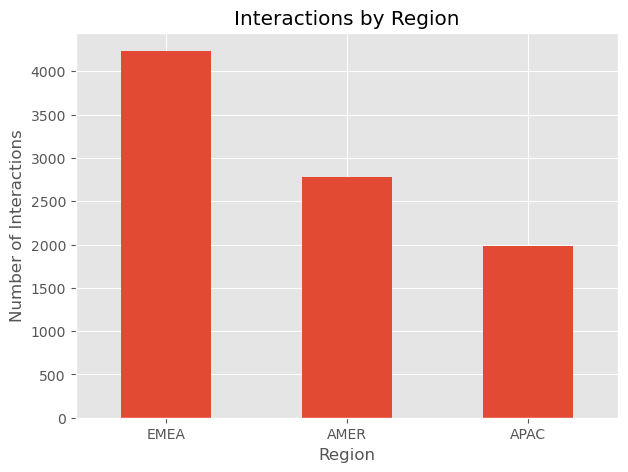

In [193]:
plt.figure(figsize=(7,5))

region_counts.plot(kind="bar")

plt.title("Interactions by Region")
plt.xlabel("Region")
plt.ylabel("Number of Interactions")

plt.xticks(rotation=0)

plt.show()

### Insight

- Different regions contribute differently to total platform usage.
- Regions with higher interaction volumes indicate stronger platform adoption.

## Customer Segment Analysis

This section examines interaction distribution across customer segments.

It helps identify which customer groups contribute the most platform activity.

In [194]:
segment_counts = interactions["segment"].value_counts()

segment_counts

segment
individual         4221
team               3087
enterprise_team    1692
Name: count, dtype: int64

### Interactions by Customer Segment

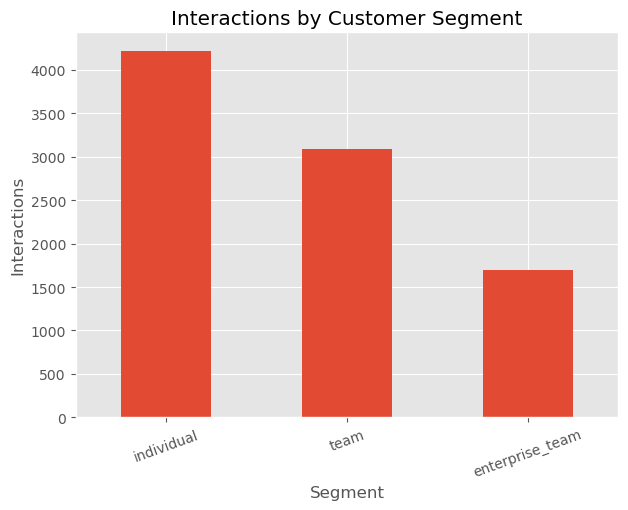

In [195]:
plt.figure(figsize=(7,5))

segment_counts.plot(kind="bar")

plt.title("Interactions by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Interactions")

plt.xticks(rotation=20)

plt.show()

### Insight

- Customer activity varies across business segments.
- Understanding customer segmentation supports targeted business strategies.

## Use Case Analysis

This section evaluates which AI use cases generate the highest interaction volume.

Understanding use case popularity helps prioritize product development and feature improvements.

In [196]:
usecase_counts = interactions["use_case"].value_counts()

usecase_counts

use_case
customer_support    2723
coding_assistant    1681
data_analysis       1454
content_writing     1441
brainstorming        909
internal_qa          792
Name: count, dtype: int64

### Interactions by Use Case

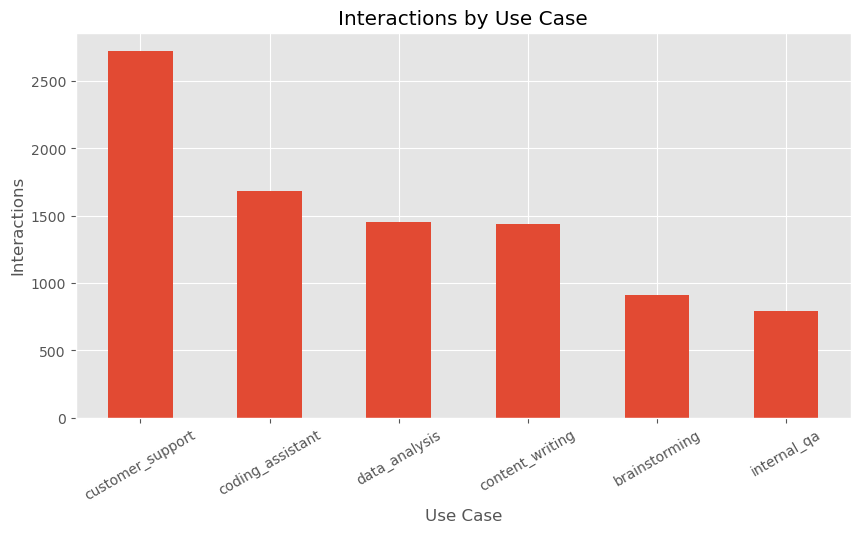

In [197]:
plt.figure(figsize=(10,5))

usecase_counts.plot(kind="bar")

plt.title("Interactions by Use Case")
plt.xlabel("Use Case")
plt.ylabel("Interactions")

plt.xticks(rotation=30)

plt.show()

### Insight

- Certain AI use cases are utilized more frequently than others.
- Frequently used use cases should receive higher optimization priority.

---

## Model Provider Analysis

This section analyzes interaction distribution across different LLM providers.

Understanding provider usage helps evaluate platform dependency and model adoption.

In [198]:
provider_counts = interactions["model_provider"].value_counts()

provider_counts

model_provider
meta         2306
openai       2247
local        1158
google       1114
mistral      1090
anthropic    1085
Name: count, dtype: int64

### Interactions by Model Provider

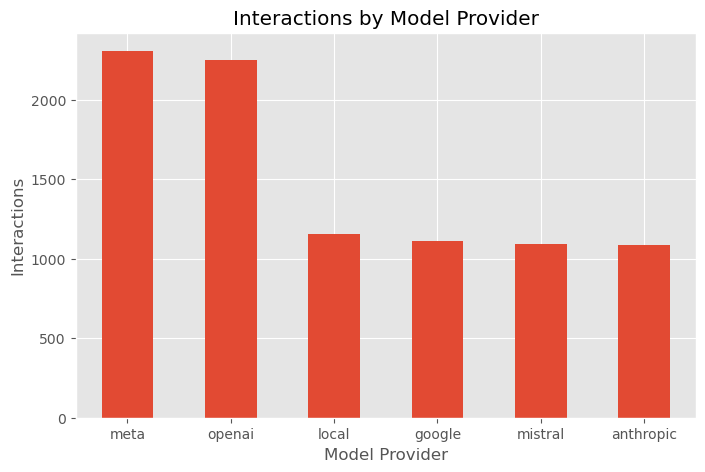

In [199]:
plt.figure(figsize=(8,5))

provider_counts.plot(kind="bar")

plt.title("Interactions by Model Provider")
plt.xlabel("Model Provider")
plt.ylabel("Interactions")

plt.xticks(rotation=0)

plt.show()

### Insight

- The platform utilizes multiple LLM providers.
- Providers with higher interaction counts represent the most frequently used models.
- This information supports provider selection and infrastructure planning.

## Model Analysis

This section evaluates the popularity of different LLM models deployed on the platform.

In [200]:
model_counts = interactions["model_name"].value_counts()

model_counts

model_name
llama-3.1-70b        1158
custom-local-8b      1158
gpt-4o-mini          1158
llama-3.1-8b         1148
gemini-1.5-pro       1114
mistral-large        1090
gpt-4.1              1089
claude-3.5-sonnet    1085
Name: count, dtype: int64

### Interactions by Model

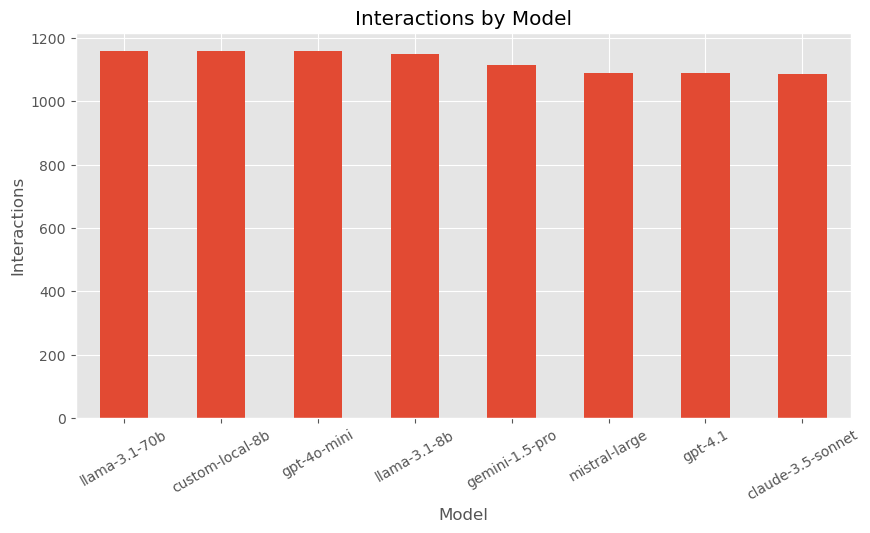

In [201]:
plt.figure(figsize=(10,5))

model_counts.plot(kind="bar")

plt.title("Interactions by Model")
plt.xlabel("Model")
plt.ylabel("Interactions")

plt.xticks(rotation=30)

plt.show()

### Insight

- Some language models receive significantly more requests than others.
- Popular models can be prioritized for optimization and scaling.

## Response Quality Analysis

This section evaluates the quality scores of generated responses.

Higher response quality contributes to improved user satisfaction and platform performance.

In [202]:
interactions["response_quality_score"].describe()

count    9000.000000
mean        0.723823
std         0.170150
min         0.088000
25%         0.607000
50%         0.729000
75%         0.853000
max         1.000000
Name: response_quality_score, dtype: float64

### Distribution of Response Quality Score

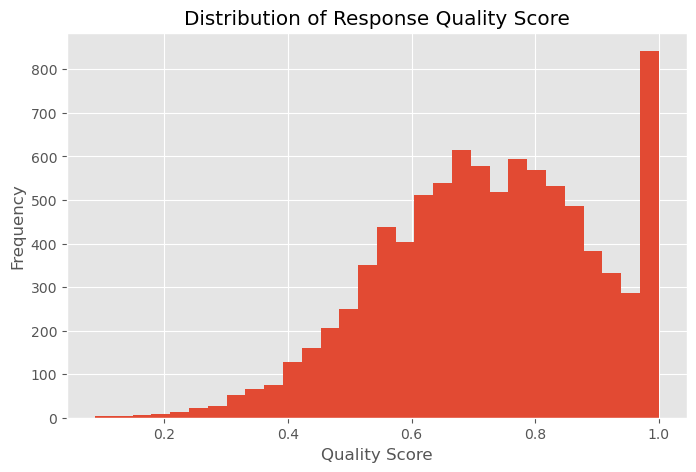

In [203]:
plt.figure(figsize=(8,5))

plt.hist(interactions["response_quality_score"], bins=30)

plt.title("Distribution of Response Quality Score")
plt.xlabel("Quality Score")
plt.ylabel("Frequency")

plt.show()

### Boxplot of Response Quality Score

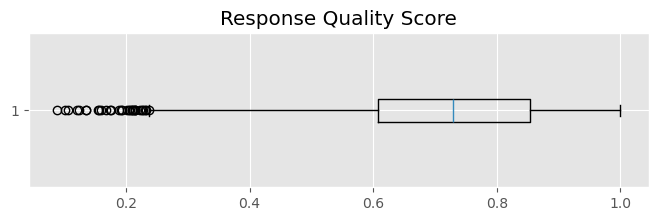

In [204]:
plt.figure(figsize=(8,2))

plt.boxplot(interactions["response_quality_score"], vert=False)

plt.title("Response Quality Score")

plt.show()

### Insight

- Most responses achieve relatively high quality scores.
- Only a small number of interactions exhibit comparatively low quality.
- Monitoring response quality helps maintain consistent platform performance.

---

## Failure Analysis

This section examines interaction failures across the platform.

Monitoring failures helps evaluate platform reliability and identify opportunities to improve operational performance.

In [205]:
failure_counts = interactions["is_failure"].value_counts()

failure_counts

is_failure
False    6443
True     2557
Name: count, dtype: int64

### Failure Distribution

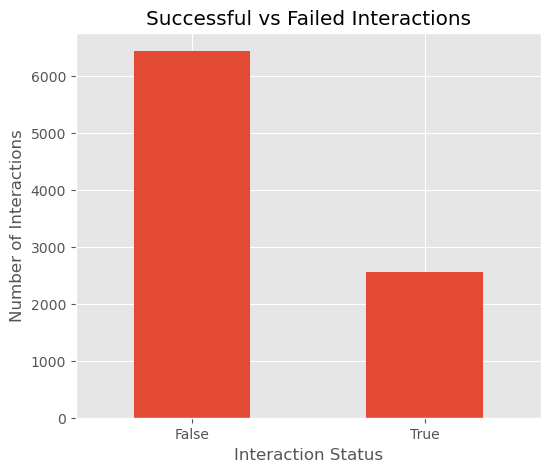

In [206]:
plt.figure(figsize=(6,5))

failure_counts.plot(kind="bar")

plt.title("Successful vs Failed Interactions")
plt.xlabel("Interaction Status")
plt.ylabel("Number of Interactions")

plt.xticks(rotation=0)

plt.show()

### Insight

- The majority of interactions complete successfully.
- Failed interactions represent a smaller proportion of platform activity.
- Reducing failures improves platform reliability and user satisfaction.

## Failure Type Analysis

This section identifies the most common categories of failures occurring on the platform.

In [207]:
failure_type_counts = interactions["failure_type"].value_counts()

failure_type_counts

failure_type
none                6443
hallucination        744
formatting_error     569
tool_error           445
safety_block         406
latency_timeout      225
toxicity             168
Name: count, dtype: int64

### Failure Types

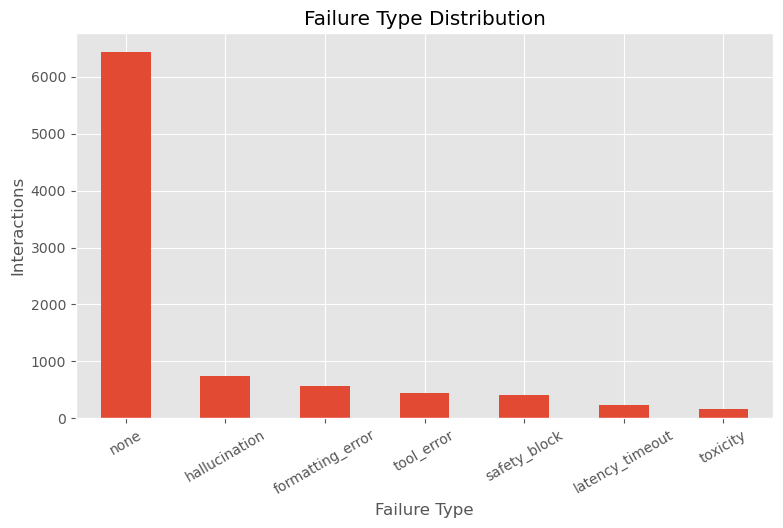

In [208]:
plt.figure(figsize=(9,5))

failure_type_counts.plot(kind="bar")

plt.title("Failure Type Distribution")
plt.xlabel("Failure Type")
plt.ylabel("Interactions")

plt.xticks(rotation=30)

plt.show()

### Insight

- Different failure types contribute differently to platform errors.
- Identifying the dominant failure categories helps prioritize reliability improvements.

## Tool Usage Analysis

This section analyzes how frequently external tools are invoked during interactions.

Tool usage reflects the complexity of user requests and platform capabilities.

In [209]:
tool_counts = interactions["tool_calls_count"].value_counts().sort_index()

tool_counts

tool_calls_count
0    6430
1    1055
2     731
3     784
Name: count, dtype: int64

### Number of Tool Calls

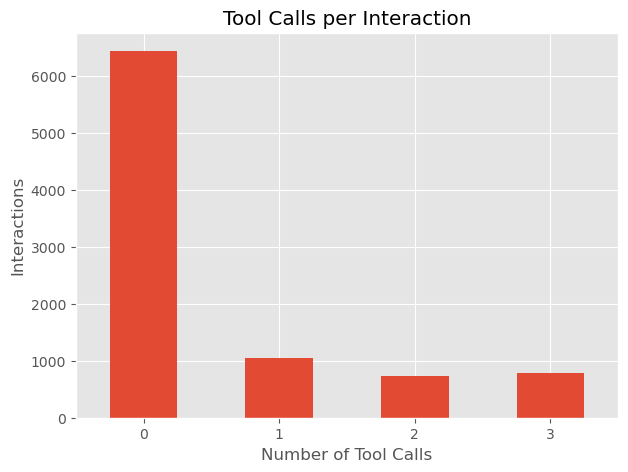

In [210]:
plt.figure(figsize=(7,5))

tool_counts.plot(kind="bar")

plt.title("Tool Calls per Interaction")
plt.xlabel("Number of Tool Calls")
plt.ylabel("Interactions")

plt.xticks(rotation=0)

plt.show()

### Insight

- Many interactions require no external tools.
- More complex interactions involve one or more tool calls.
- Tool usage patterns provide insight into platform capabilities and workload complexity.

## Hallucination Analysis

This section examines how frequently hallucinations are detected in model responses.

Reducing hallucinations improves response reliability and user trust.

In [211]:
hallucination_counts = interactions["hallucination_flag"].value_counts()

hallucination_counts

hallucination_flag
False    8256
True      744
Name: count, dtype: int64

### Hallucination Distribution

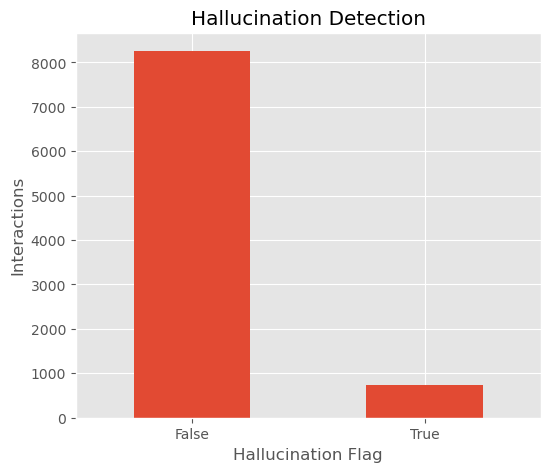

In [212]:
plt.figure(figsize=(6,5))

hallucination_counts.plot(kind="bar")

plt.title("Hallucination Detection")
plt.xlabel("Hallucination Flag")
plt.ylabel("Interactions")

plt.xticks(rotation=0)

plt.show()

### Insight

- Most interactions do not contain hallucinations.
- A small percentage are flagged for hallucination risk.
- Monitoring hallucinations helps improve response reliability and user trust.

## Toxicity Analysis

This section evaluates how often generated responses are flagged for toxicity.

Maintaining low toxicity is essential for safe and responsible AI systems.

In [213]:
toxicity_counts = interactions["toxicity_flag"].value_counts()

toxicity_counts

toxicity_flag
False    8832
True      168
Name: count, dtype: int64

### Toxicity Distribution

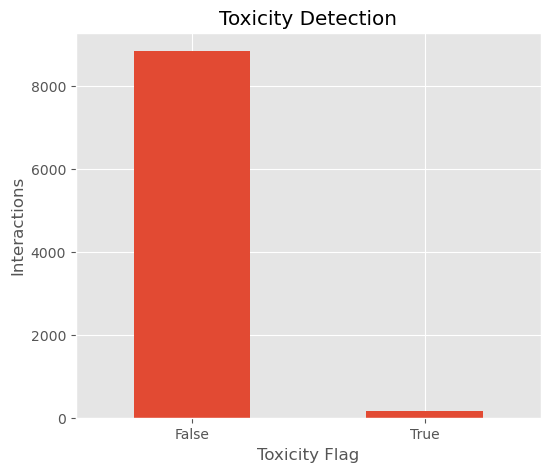

In [214]:
plt.figure(figsize=(6,5))

toxicity_counts.plot(kind="bar")

plt.title("Toxicity Detection")
plt.xlabel("Toxicity Flag")
plt.ylabel("Interactions")

plt.xticks(rotation=0)

plt.show()

### Insight

- Most interactions are non-toxic.
- Only a small number are flagged for toxicity.
- Toxicity monitoring ensures responsible AI deployment.

## Safety Block Analysis

This section analyzes interactions blocked by platform safety mechanisms.

Safety blocks protect users from harmful or unsafe content.

In [215]:
safety_counts = interactions["safety_block_flag"].value_counts()

safety_counts

safety_block_flag
False    8594
True      406
Name: count, dtype: int64

### Safety Block Distribution

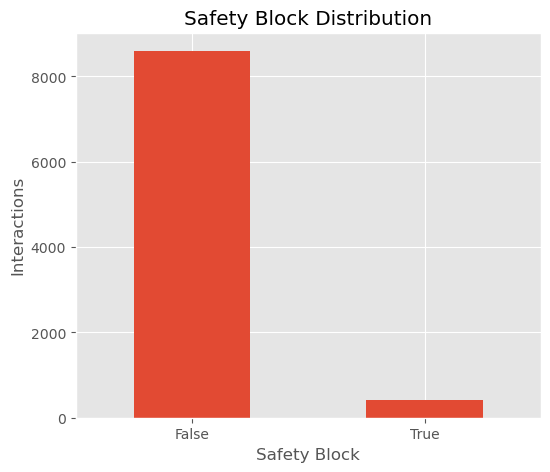

In [216]:
plt.figure(figsize=(6,5))

safety_counts.plot(kind="bar")

plt.title("Safety Block Distribution")
plt.xlabel("Safety Block")
plt.ylabel("Interactions")

plt.xticks(rotation=0)

plt.show()

### Insight

- Most interactions complete without safety intervention.
- A small number are blocked due to safety policies.
- Safety monitoring improves platform security and responsible AI usage.

## User Feedback Analysis

This section evaluates user satisfaction based on feedback scores.

User feedback is an important indicator of platform performance and response quality.

In [217]:
interactions["user_feedback_score"].describe()

count    4880.000000
mean        0.603893
std         1.334989
min        -2.000000
25%         0.000000
50%         1.000000
75%         2.000000
max         2.000000
Name: user_feedback_score, dtype: float64

### Distribution of User Feedback Score

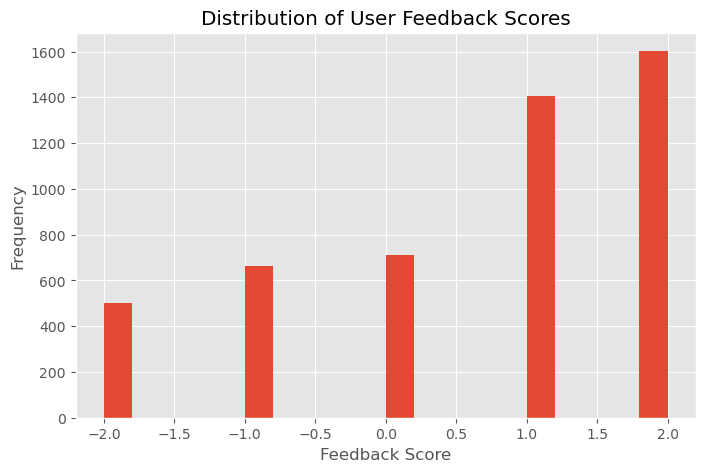

In [218]:
plt.figure(figsize=(8,5))

plt.hist(interactions["user_feedback_score"].dropna(), bins=20)

plt.title("Distribution of User Feedback Scores")
plt.xlabel("Feedback Score")
plt.ylabel("Frequency")

plt.show()

### Insight

- Most feedback scores are positive.
- Missing feedback represents users who did not submit ratings.
- User feedback helps measure customer satisfaction and identify improvement opportunities.

---

## Hour of Day Analysis

This section examines how interactions are distributed throughout the day.

Understanding hourly usage patterns helps identify peak platform activity and supports capacity planning.

In [219]:
hour_counts = interactions["hour_of_day_utc"].value_counts().sort_index()

hour_counts

hour_of_day_utc
0     259
1     267
2     295
3     290
4     231
5     137
6     226
7     441
8     605
9     666
10    708
11    402
12    168
13    382
14    469
15    648
16    684
17    437
18    184
19    259
20    299
21    337
22    357
23    249
Name: count, dtype: int64

### Interaction Distribution by Hour

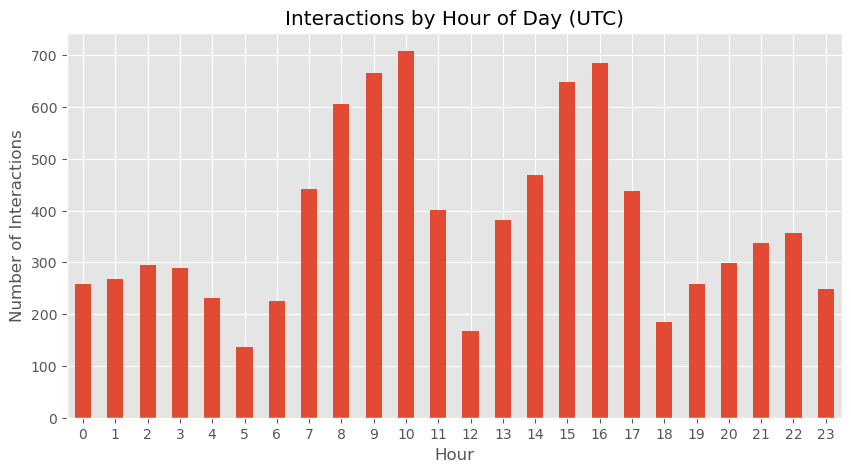

In [220]:
plt.figure(figsize=(10,5))

hour_counts.plot(kind="bar")

plt.title("Interactions by Hour of Day (UTC)")
plt.xlabel("Hour")
plt.ylabel("Number of Interactions")

plt.xticks(rotation=0)

plt.show()


### Insight

- User activity varies across different hours of the day.
- Certain hours experience noticeably higher interaction volumes.
- Identifying peak hours helps optimize infrastructure and resource allocation.

## Day of Week Analysis

This section analyzes interaction activity across the days of the week.

Daily usage trends provide insight into user engagement patterns.

In [221]:
day_counts = interactions["day_of_week"].value_counts().sort_index()

day_counts

day_of_week
0    1409
1    1847
2    1558
3    1432
4    1375
5     694
6     685
Name: count, dtype: int64

### Interaction Distribution by Day

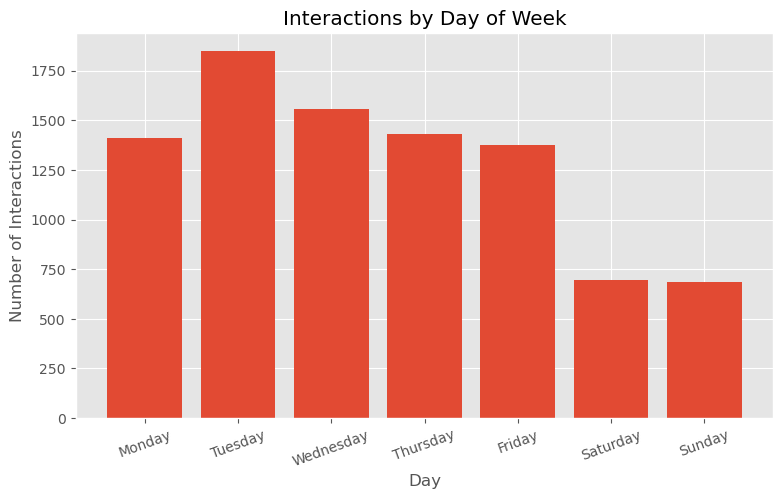

In [222]:
day_labels = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

plt.figure(figsize=(9,5))

plt.bar(day_labels, day_counts.values)

plt.title("Interactions by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Interactions")

plt.xticks(rotation=20)

plt.show()

### Insight

- Interaction volumes vary across weekdays and weekends.
- Identifying busy days supports workload forecasting and operational planning.

## Weekend vs Weekday Analysis

This section compares interaction volumes between weekdays and weekends.

This helps understand differences in user engagement across the week.

In [223]:
weekend_counts = interactions["is_weekend"].value_counts()

weekend_counts

is_weekend
False    7621
True     1379
Name: count, dtype: int64

### Weekend Distribution

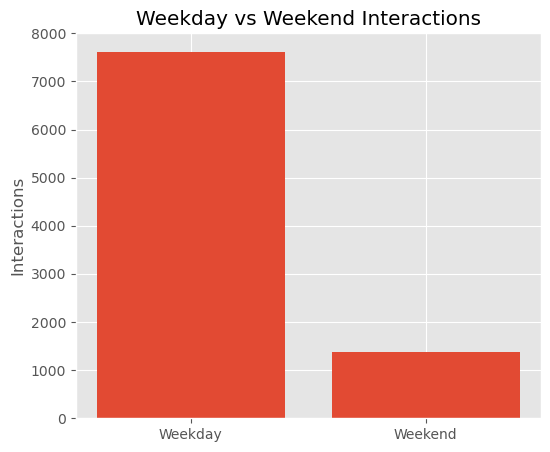

In [224]:
plt.figure(figsize=(6,5))

plt.bar(
    ["Weekday", "Weekend"],
    [
        weekend_counts.get(False, 0),
        weekend_counts.get(True, 0)
    ]
)

plt.title("Weekday vs Weekend Interactions")
plt.ylabel("Interactions")

plt.show()

### Insight

- Most platform activity occurs on weekdays.
- Weekend usage remains significant but comparatively lower.
- These trends help estimate demand throughout the week.

## Peak Hour Analysis

This section evaluates interactions during peak and non-peak hours.

Understanding peak-hour traffic helps improve platform scalability and performance.

In [225]:
peak_counts = interactions["is_peak_hour"].value_counts()

peak_counts

is_peak_hour
True     4748
False    4252
Name: count, dtype: int64

### Peak Hour Distribution

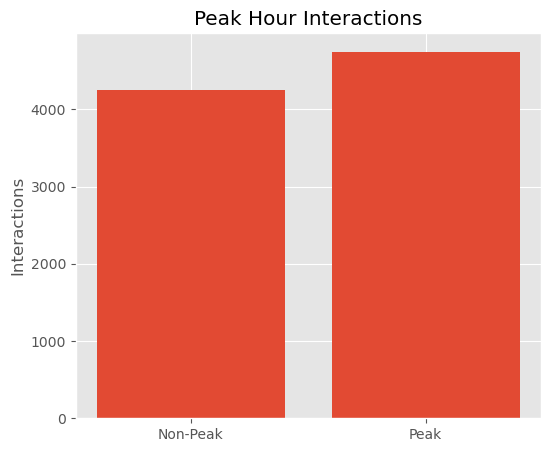

In [226]:
plt.figure(figsize=(6,5))

plt.bar(
    ["Non-Peak", "Peak"],
    [
        peak_counts.get(False, 0),
        peak_counts.get(True, 0)
    ]
)

plt.title("Peak Hour Interactions")
plt.ylabel("Interactions")

plt.show()

### Insight

- A substantial portion of interactions occurs during peak hours.
- Peak traffic periods require efficient resource allocation to maintain platform performance.
- Understanding these patterns supports capacity planning and operational optimization.

---

# Exploratory Data Analysis Summary

The exploratory data analysis examined user behavior, platform usage, operational performance, response quality, cost, reliability, and temporal activity across the LLM platform.

Key findings include:

- User activity is distributed across multiple countries, regions, and communication channels.
- Most interactions generate moderate token usage, latency, and inference cost.
- Response quality scores are generally high, indicating good overall model performance.
- Platform failures, hallucinations, toxicity, and safety blocks occur infrequently, demonstrating stable system behavior.
- User feedback is largely positive, reflecting satisfactory user experience.
- Interaction activity varies across hours and days, providing valuable insights for infrastructure planning and workload optimization.

These findings provide a strong analytical foundation for the SQL analysis and Power BI dashboard, supporting the project's objectives of improving user engagement, product adoption, operational efficiency, platform reliability, and cost optimization.